# Notebook 04: PPO com Self-Play

Este notebook é dedicado ao treino, avaliação e análise do agente `PPO` do projeto.

## Objetivo

O objetivo deste notebook é:

- treinar o `PPO`;
- comparar variantes de configuração;
- analisar checkpoints guardados;
- medir evolução contra baselines e contra versões anteriores;
- observar partidas concretas.

## Passo 1: Preparação do ambiente

Importamos o código do projeto, os agentes baseline, o agente `PPO`, as utilidades gráficas e a pasta `outputs/`.

In [1]:
from __future__ import annotations

import json
import statistics
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

OUTPUTS = ROOT / "outputs"
NOTEBOOK_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TORCH_DEVICE = torch.device(NOTEBOOK_DEVICE)
if NOTEBOOK_DEVICE == "cuda":
    torch.set_default_device(TORCH_DEVICE)
print(
    {
        "torch_version": torch.__version__,
        "cuda_available": torch.cuda.is_available(),
        "cuda_device_count": torch.cuda.device_count(),
        "device": NOTEBOOK_DEVICE,
        "cuda_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    }
)
OUTPUTS

from connect4_rl.agents.baselines import HeuristicAgent, RandomAgent
from connect4_rl.agents.learning import PPOAgent, PPOConfig
from connect4_rl.envs.connect_four import apply_action, initial_state, is_terminal, legal_actions, render_ascii
from connect4_rl.experiments import compute_elo_ratings, round_robin_detailed
from connect4_rl.experiments.ppo_training import train_ppo_self_play


{'torch_version': '2.11.0+cu130', 'cuda_available': True, 'cuda_device_count': 1, 'device': 'cuda', 'cuda_name': 'NVIDIA GeForce RTX 5060 Laptop GPU'}


## Passo 2: Configuração do treino de PPO

Nesta célula definimos o comportamento principal do notebook.

- `train_from_notebook`: se estiver a `True`, o notebook lança um novo treino de `PPO`.
- `run_ablation_from_notebook`: se estiver a `True`, o notebook testa várias configurações de `PPO`.
- `run_checkpoint_elo`: se estiver a `True`, calcula `Elo` entre checkpoints do mesmo treino.
- `training_config`: contém os hiperparâmetros principais do treino.
- `checkpoint_dir`: pasta onde ficam guardados checkpoints e métricas.

In [2]:
train_from_notebook = True
# Se True, corre uma pequena ablação de configurações de PPO.
run_ablation_from_notebook = True

training_config = PPOConfig(
    episodes=180,
    eval_interval=30,
    eval_games=12,
    seed=7,
    device=NOTEBOOK_DEVICE,
)

run_name = f"ppo_notebook_seed_{training_config.seed}"
checkpoint_dir = OUTPUTS / run_name
# Se True, calcula Elo entre vários checkpoints do mesmo treino.
run_checkpoint_elo = True

ablation_episodes = 180
ablation_seeds = [7, 17, 27]
ablation_builders = {
    "base": lambda seed: PPOConfig(
        episodes=ablation_episodes,
        eval_interval=30,
        eval_games=12,
        seed=seed,
        device=NOTEBOOK_DEVICE,
    ),
    "no_shaping": lambda seed: PPOConfig(
        episodes=ablation_episodes,
        eval_interval=30,
        eval_games=12,
        use_reward_shaping=False,
        seed=seed,
        device=NOTEBOOK_DEVICE,
    ),
    "conservative": lambda seed: PPOConfig(
        episodes=ablation_episodes,
        eval_interval=30,
        eval_games=12,
        learning_rate=1.5e-4,
        entropy_coef=0.01,
        rollout_episodes_per_update=12,
        seed=seed,
        device=NOTEBOOK_DEVICE,
    ),
}

training_config, checkpoint_dir


(PPOConfig(episodes=180, gamma=0.99, gae_lambda=0.95, learning_rate=0.00025, clip_epsilon=0.2, value_loss_coef=0.5, entropy_coef=0.02, update_epochs=6, minibatch_size=32, hidden_dim=256, rollout_episodes_per_update=8, opponent_refresh_interval=20, opponent_pool_size=5, warmup_episodes=40, random_opponent_fraction=0.2, heuristic_opponent_fraction=0.15, eval_interval=30, eval_games=12, seed=7, device='cuda', checkpoint_score_heuristic_weight=2.0, use_horizontal_symmetry_augmentation=True, max_grad_norm=1.0, anneal_learning_rate=True, use_reward_shaping=True, reward_shaping_scale=0.05),
 PosixPath('/home/pcabrita/MIA/AR/TP/AR/outputs/ppo_notebook_seed_7'))

## Passo 3: Treino principal do PPO

Se o treino estiver ativado, esta célula lança uma corrida de `PPO` em self-play e apresenta um resumo inicial.

In [3]:
# `None` significa que ainda não existe um treino lançado nesta sessão do notebook.
trained_agent = None
trained_metrics = None

if train_from_notebook:
    trained_agent, trained_metrics = train_ppo_self_play(training_config, checkpoint_dir=checkpoint_dir)
    print({
        "episodes": len(trained_metrics.episode_rewards),
        "best_score": trained_metrics.best_score,
        "last_eval": trained_metrics.evaluation[-1] if trained_metrics.evaluation else {},
        "best_checkpoint_path": trained_metrics.best_checkpoint_path,
    })
else:
    print("Notebook training skipped.")


{'episodes': 180, 'best_score': 0.9166666666666666, 'last_eval': {'episode': 180.0, 'vs_random_win_rate': 0.9166666666666666, 'vs_heuristic_win_rate': 0.0, 'vs_previous_win_rate': 0.5}, 'best_checkpoint_path': '/home/pcabrita/MIA/AR/TP/AR/outputs/ppo_notebook_seed_7/ppo_best.pt'}


## Passo 4: Ablação opcional do PPO

Esta célula permite testar variantes do `PPO` para perceber se alguma configuração se destaca das restantes.

In [4]:
# Dicionário onde serão guardados os resultados da ablação, se ela for executada.
ablation_summary = {}

if run_ablation_from_notebook:
    for name, builder in ablation_builders.items():
        runs = []
        for seed in ablation_seeds:
            config = builder(seed)
            _, metrics = train_ppo_self_play(config, checkpoint_dir=OUTPUTS / f"ppo_ablation_{name}_seed_{seed}")
            last_eval = metrics.evaluation[-1] if metrics.evaluation else {}
            runs.append({
                "seed": seed,
                "best_score": metrics.best_score,
                "last_vs_random": float(last_eval.get("vs_random_win_rate", 0.0)),
                "last_vs_heuristic": float(last_eval.get("vs_heuristic_win_rate", 0.0)),
                "policy_updates": len(metrics.policy_losses),
                "mean_reward_last_20": statistics.fmean(metrics.episode_rewards[-20:]) if metrics.episode_rewards else 0.0,
            })

        ablation_summary[name] = {
            "runs": runs,
            "mean_best_score": statistics.fmean(run["best_score"] for run in runs),
            "mean_last_vs_random": statistics.fmean(run["last_vs_random"] for run in runs),
            "mean_last_vs_heuristic": statistics.fmean(run["last_vs_heuristic"] for run in runs),
            "mean_reward_last_20": statistics.fmean(run["mean_reward_last_20"] for run in runs),
        }

    print(json.dumps(ablation_summary, indent=2))
else:
    print("Notebook ablation skipped. Use saved runs below for analysis.")


{
  "base": {
    "runs": [
      {
        "seed": 7,
        "best_score": 0.9166666666666666,
        "last_vs_random": 0.75,
        "last_vs_heuristic": 0.0,
        "policy_updates": 23,
        "mean_reward_last_20": 0.0
      },
      {
        "seed": 17,
        "best_score": 0.8333333333333334,
        "last_vs_random": 0.8333333333333334,
        "last_vs_heuristic": 0.0,
        "policy_updates": 23,
        "mean_reward_last_20": -0.1
      },
      {
        "seed": 27,
        "best_score": 0.9166666666666666,
        "last_vs_random": 0.9166666666666666,
        "last_vs_heuristic": 0.0,
        "policy_updates": 23,
        "mean_reward_last_20": -0.2
      }
    ],
    "mean_best_score": 0.8888888888888888,
    "mean_last_vs_random": 0.8333333333333334,
    "mean_last_vs_heuristic": 0.0,
    "mean_reward_last_20": -0.10000000000000002
  },
  "no_shaping": {
    "runs": [
      {
        "seed": 7,
        "best_score": 0.9166666666666666,
        "last_vs_random": 0.

## Passo 5: Carregamento das corridas guardadas

Aqui recolhemos os ficheiros de métricas já guardados para o `PPO`, o que permite análise sem repetir treino.

In [5]:
def load_metrics_files(root: Path) -> list[dict]:
    runs = []
    for metrics_path in sorted(root.glob("**/metrics_final.json")):
        if "ppo" not in metrics_path.parent.name:
            continue
        data = json.loads(metrics_path.read_text(encoding="utf-8"))
        run_name = metrics_path.parent.name
        family = run_name.split("_seed_")[0] if "_seed_" in run_name else run_name
        runs.append({
            "run_name": run_name,
            "family": family,
            "path": metrics_path,
            "data": data,
        })
    return runs

all_runs = load_metrics_files(OUTPUTS)
[(run["run_name"], len(run["data"].get("evaluation", []))) for run in all_runs]


[('ppo_ablation_base_seed_17', 6),
 ('ppo_ablation_base_seed_27', 6),
 ('ppo_ablation_base_seed_7', 6),
 ('ppo_ablation_conservative_seed_17', 6),
 ('ppo_ablation_conservative_seed_27', 6),
 ('ppo_ablation_conservative_seed_7', 6),
 ('ppo_ablation_no_shaping_seed_17', 6),
 ('ppo_ablation_no_shaping_seed_27', 6),
 ('ppo_ablation_no_shaping_seed_7', 6),
 ('ppo_notebook_seed_7', 6)]

## Passo 6: Agregação e ranking das corridas

Nesta célula resumimos as corridas por família de configuração e ordenamos os resultados.

In [6]:
def summarize_runs(runs: list[dict]) -> dict[str, dict]:
    grouped: dict[str, list[dict]] = {}
    for run in runs:
        grouped.setdefault(run["family"], []).append(run)

    summary = {}
    for family, family_runs in grouped.items():
        best_scores = [run["data"].get("best_score", float("-inf")) for run in family_runs]
        last_random = []
        last_heuristic = []
        last_previous = []
        last_reward = []
        for run in family_runs:
            evaluations = run["data"].get("evaluation", [])
            if evaluations:
                last_random.append(float(evaluations[-1].get("vs_random_win_rate", 0.0)))
                last_heuristic.append(float(evaluations[-1].get("vs_heuristic_win_rate", 0.0)))
                last_previous.append(float(evaluations[-1].get("vs_previous_win_rate", 0.0)))
            rewards = run["data"].get("episode_rewards", [])
            if rewards:
                last_reward.append(statistics.fmean(rewards[-20:]))

        summary[family] = {
            "num_runs": len(family_runs),
            "mean_best_score": statistics.fmean(best_scores) if best_scores else float("-inf"),
            "mean_last_vs_random": statistics.fmean(last_random) if last_random else 0.0,
            "mean_last_vs_heuristic": statistics.fmean(last_heuristic) if last_heuristic else 0.0,
            "mean_last_vs_previous": statistics.fmean(last_previous) if last_previous else 0.0,
            "mean_reward_last_20": statistics.fmean(last_reward) if last_reward else 0.0,
        }
    return summary

summary = summarize_runs(all_runs)
ranking = sorted(
    summary.items(),
    key=lambda item: (
        item[1]["mean_last_vs_heuristic"],
        item[1]["mean_best_score"],
        item[1]["mean_last_vs_random"],
    ),
    reverse=True,
)
ranking


[('ppo_ablation_no_shaping',
  {'num_runs': 3,
   'mean_best_score': 1.1388888888888888,
   'mean_last_vs_random': 0.8333333333333334,
   'mean_last_vs_heuristic': 0.08333333333333333,
   'mean_last_vs_previous': 0.5,
   'mean_reward_last_20': -0.06666666666666667}),
 ('ppo_notebook',
  {'num_runs': 1,
   'mean_best_score': 0.9166666666666666,
   'mean_last_vs_random': 0.9166666666666666,
   'mean_last_vs_heuristic': 0.0,
   'mean_last_vs_previous': 0.5,
   'mean_reward_last_20': 0.3}),
 ('ppo_ablation_conservative',
  {'num_runs': 3,
   'mean_best_score': 0.9166666666666666,
   'mean_last_vs_random': 0.861111111111111,
   'mean_last_vs_heuristic': 0.0,
   'mean_last_vs_previous': 0.3333333333333333,
   'mean_reward_last_20': 0.09999999999999999}),
 ('ppo_ablation_base',
  {'num_runs': 3,
   'mean_best_score': 0.8888888888888888,
   'mean_last_vs_random': 0.8333333333333334,
   'mean_last_vs_heuristic': 0.0,
   'mean_last_vs_previous': 0.5,
   'mean_reward_last_20': -0.1000000000000000

## Passo 7: Gráficos agregados do PPO

Aqui desenhamos gráficos do desempenho do `PPO`, incluindo progresso contra baselines e contra a versão anterior.

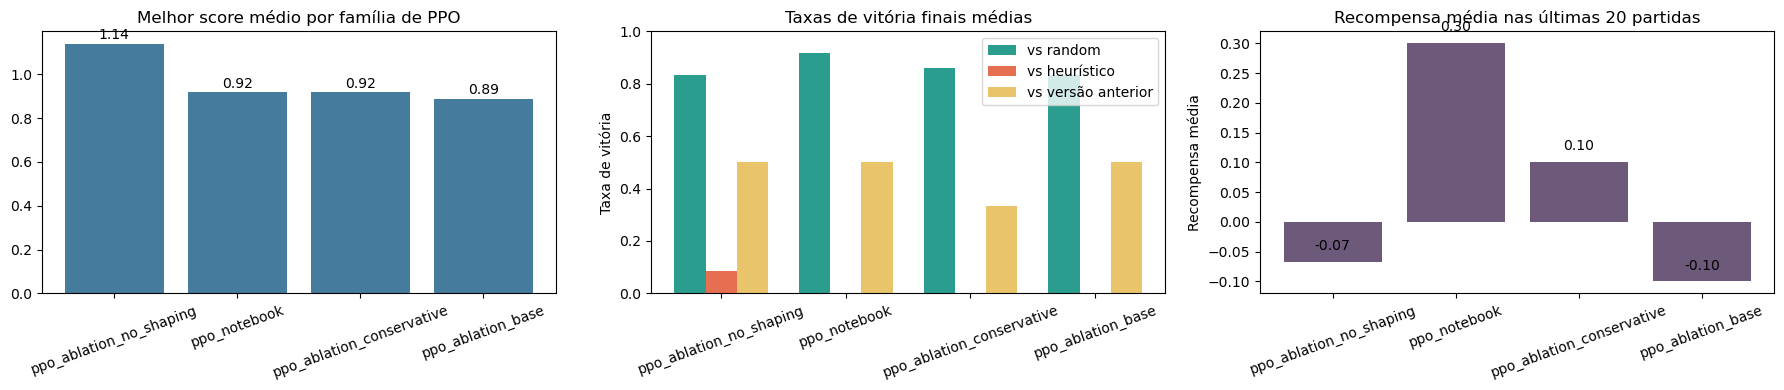

In [7]:
if ranking:
    families = [name for name, _stats in ranking]
    mean_best = [summary[name]["mean_best_score"] for name in families]
    mean_random = [summary[name]["mean_last_vs_random"] for name in families]
    mean_heur = [summary[name]["mean_last_vs_heuristic"] for name in families]
    mean_previous = [summary[name]["mean_last_vs_previous"] for name in families]
    mean_reward = [summary[name]["mean_reward_last_20"] for name in families]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].bar(families, mean_best, color="#457b9d")
    axes[0].set_title("Melhor score médio por família de PPO")
    axes[0].tick_params(axis="x", rotation=20)
    for idx, value in enumerate(mean_best):
        axes[0].text(idx, value + 0.02, f"{value:.2f}", ha="center")

    x = list(range(len(families)))
    width = 0.25
    axes[1].bar([value - width for value in x], mean_random, width=width, label="vs random", color="#2a9d8f")
    axes[1].bar(x, mean_heur, width=width, label="vs heurístico", color="#e76f51")
    axes[1].bar([value + width for value in x], mean_previous, width=width, label="vs versão anterior", color="#e9c46a")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(families, rotation=20)
    axes[1].set_ylim(0.0, 1.0)
    axes[1].set_title("Taxas de vitória finais médias")
    axes[1].set_ylabel("Taxa de vitória")
    axes[1].legend()

    axes[2].bar(families, mean_reward, color="#6d597a")
    axes[2].set_title("Recompensa média nas últimas 20 partidas")
    axes[2].tick_params(axis="x", rotation=20)
    axes[2].set_ylabel("Recompensa média")
    for idx, value in enumerate(mean_reward):
        axes[2].text(idx, value + 0.02, f"{value:.2f}", ha="center")

    fig.tight_layout()
    plt.show()


## Passo 8: Escolha do melhor checkpoint

Nesta célula carregamos o checkpoint que representa a melhor versão guardada do `PPO`.

In [8]:
def pick_best_run(runs: list[dict]) -> dict:
    def sort_key(run: dict):
        evaluations = run["data"].get("evaluation", [])
        last = evaluations[-1] if evaluations else {}
        return (
            float(last.get("vs_heuristic_win_rate", 0.0)),
            run["data"].get("best_score", float("-inf")),
            float(last.get("vs_random_win_rate", 0.0)),
        )

    return max(runs, key=sort_key)

# `None` significa que ainda não foi carregado nenhum checkpoint vencedor.
ppo_agent = None
if all_runs:
    best_run = pick_best_run(all_runs)
    checkpoint_path = ROOT / best_run["data"]["best_checkpoint_path"]
    config = best_run["data"].get("config", {})
    ppo_agent = PPOAgent.from_checkpoint(
        checkpoint_path,
        device=NOTEBOOK_DEVICE,
        sample_actions=False,
        seed=int(config.get("seed", 0)),
        hidden_dim=int(config.get("hidden_dim", 128)),
    )
    print({
        "best_run": best_run["run_name"],
        "checkpoint": str(checkpoint_path),
    })
else:
    print("No PPO runs found under outputs/.")


{'best_run': 'ppo_ablation_no_shaping_seed_17', 'checkpoint': '/home/pcabrita/MIA/AR/TP/AR/outputs/ppo_ablation_no_shaping_seed_17/ppo_best.pt'}


### Curvas detalhadas do melhor treino

Esta secção mostra a evolução temporal do melhor treino encontrado. Os gráficos foram separados por objetivo para ser mais fácil perceber se o agente está realmente a melhorar ao longo do treino.

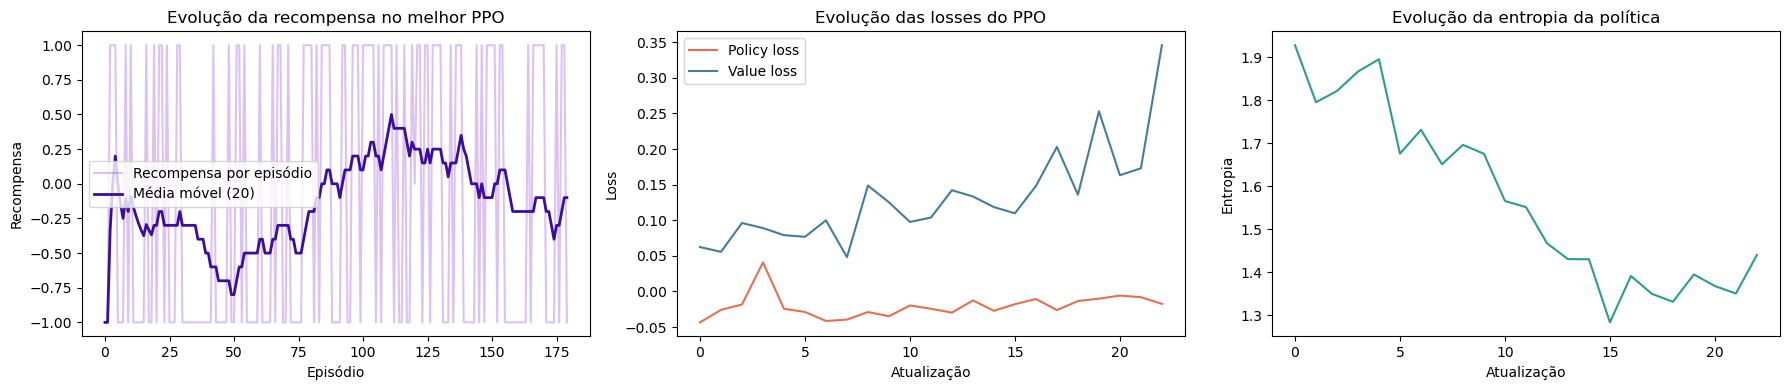

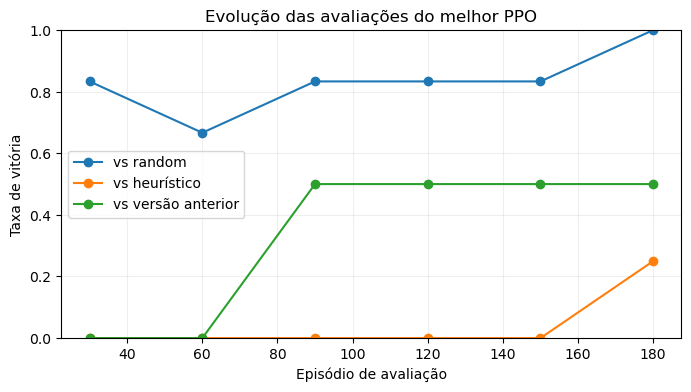

In [9]:
def rolling_mean(values: list[float], window: int = 20) -> list[float]:
    if not values:
        return []
    return [statistics.fmean(values[max(0, idx - window + 1): idx + 1]) for idx in range(len(values))]

if all_runs:
    rewards = [float(value) for value in best_run["data"].get("episode_rewards", [])]
    policy_losses = [float(value) for value in best_run["data"].get("policy_losses", [])]
    value_losses = [float(value) for value in best_run["data"].get("value_losses", [])]
    entropies = [float(value) for value in best_run["data"].get("entropies", [])]
    evaluations = best_run["data"].get("evaluation", [])

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    if rewards:
        axes[0].plot(rewards, color="#9d4edd", alpha=0.35, label="Recompensa por episódio")
        axes[0].plot(rolling_mean(rewards, window=20), color="#3a0ca3", linewidth=2, label="Média móvel (20)")
        axes[0].set_title("Evolução da recompensa no melhor PPO")
        axes[0].set_xlabel("Episódio")
        axes[0].set_ylabel("Recompensa")
        axes[0].legend()
    else:
        axes[0].set_title("Sem recompensas registadas")
        axes[0].axis("off")

    if policy_losses or value_losses:
        if policy_losses:
            axes[1].plot(policy_losses, label="Policy loss", color="#e76f51")
        if value_losses:
            axes[1].plot(value_losses, label="Value loss", color="#457b9d")
        axes[1].set_title("Evolução das losses do PPO")
        axes[1].set_xlabel("Atualização")
        axes[1].set_ylabel("Loss")
        axes[1].legend()
    else:
        axes[1].set_title("Sem losses registadas")
        axes[1].axis("off")

    if entropies:
        axes[2].plot(entropies, color="#2a9d8f")
        axes[2].set_title("Evolução da entropia da política")
        axes[2].set_xlabel("Atualização")
        axes[2].set_ylabel("Entropia")
    else:
        axes[2].set_title("Sem entropias registadas")
        axes[2].axis("off")

    fig.tight_layout()
    plt.show()

    if evaluations:
        eval_episodes = [int(item.get("episode", 0)) for item in evaluations]
        vs_random = [float(item.get("vs_random_win_rate", 0.0)) for item in evaluations]
        vs_heuristic = [float(item.get("vs_heuristic_win_rate", 0.0)) for item in evaluations]
        vs_previous = [float(item.get("vs_previous_win_rate", 0.0)) for item in evaluations]

        plt.figure(figsize=(8, 4))
        plt.plot(eval_episodes, vs_random, marker="o", label="vs random")
        plt.plot(eval_episodes, vs_heuristic, marker="o", label="vs heurístico")
        plt.plot(eval_episodes, vs_previous, marker="o", label="vs versão anterior")
        plt.ylim(0.0, 1.0)
        plt.title("Evolução das avaliações do melhor PPO")
        plt.xlabel("Episódio de avaliação")
        plt.ylabel("Taxa de vitória")
        plt.legend()
        plt.grid(alpha=0.2)
        plt.show()


## Passo 9: Torneio entre checkpoints e cálculo de Elo

Se a opção correspondente estiver ativa, esta célula calcula um torneio entre checkpoints do `PPO` e estima o respetivo `Elo`.

In [10]:
if ppo_agent is not None and run_checkpoint_elo:
    checkpoint_files = sorted(checkpoint_path.parent.glob("ppo_episode_*.pt"))
    step = max(len(checkpoint_files) // 4, 1)
    selected = checkpoint_files[::step][:5]
    if checkpoint_files and checkpoint_files[-1] not in selected:
        selected.append(checkpoint_files[-1])

    checkpoint_factories = {}
    for path in selected:
        label = path.stem.replace("ppo_episode_", "ppo_")
        checkpoint_factories[label] = lambda cp=path, cfg=config: PPOAgent.from_checkpoint(
            cp,
            device=NOTEBOOK_DEVICE,
            sample_actions=False,
            seed=int(cfg.get("seed", 0)),
            hidden_dim=int(cfg.get("hidden_dim", 128)),
        )

    checkpoint_scores, checkpoint_matches = round_robin_detailed(checkpoint_factories, games_per_pair=24)
    checkpoint_elo = compute_elo_ratings(checkpoint_matches)
    print(checkpoint_scores)
    print(checkpoint_elo)
else:
    print("Set run_checkpoint_elo = True after training to compute PPO checkpoint Elo.")


{'ppo_0030': {'wins': 48.0, 'games': 120.0, 'losses': 72.0, 'win_rate': 0.4, 'draws': 0.0, 'draw_rate': 0.0}, 'ppo_0060': {'losses': 48.0, 'games': 120.0, 'wins': 72.0, 'win_rate': 0.6, 'draws': 0.0, 'draw_rate': 0.0}, 'ppo_0090': {'wins': 48.0, 'games': 120.0, 'losses': 72.0, 'win_rate': 0.4, 'draws': 0.0, 'draw_rate': 0.0}, 'ppo_0120': {'losses': 72.0, 'games': 120.0, 'wins': 48.0, 'win_rate': 0.4, 'draws': 0.0, 'draw_rate': 0.0}, 'ppo_0150': {'losses': 48.0, 'games': 120.0, 'wins': 72.0, 'win_rate': 0.6, 'draws': 0.0, 'draw_rate': 0.0}, 'ppo_0180': {'wins': 72.0, 'games': 120.0, 'losses': 48.0, 'win_rate': 0.6, 'draws': 0.0, 'draw_rate': 0.0}}
{'ppo_0030': 1360.41, 'ppo_0120': 1351.92, 'ppo_0060': 1317.8, 'ppo_0090': 1222.34, 'ppo_0150': 1107.35, 'ppo_0180': 840.18}


## Passo 10: Testes finais e visualização do PPO

Aqui avaliamos o melhor `PPO` contra os baselines e renderizamos uma partida concreta para análise qualitativa.

In [11]:
def evaluate_agent(agent, opponent_factory, games: int = 20) -> float:
    wins = 0
    for game_idx in range(games):
        controlled_player = 1 if game_idx % 2 == 0 else 2
        try:
            opponent = opponent_factory(game_idx)
        except TypeError:
            opponent = opponent_factory()
        state = initial_state()
        while not is_terminal(state):
            if state.current_player == controlled_player:
                action = agent.select_action(state, legal_actions(state))
            else:
                action = opponent.select_action(state, legal_actions(state))
            state = apply_action(state, action)
        if state.winner == controlled_player:
            wins += 1
    return wins / games


def play_and_render(agent, opponent, controlled_player: int = 1) -> str:
    state = initial_state()
    transcript = ["Initial board", render_ascii(state), ""]
    move_idx = 0
    while not is_terminal(state):
        move_idx += 1
        if state.current_player == controlled_player:
            action = agent.select_action(state, legal_actions(state))
            actor = agent.name
        else:
            action = opponent.select_action(state, legal_actions(state))
            actor = opponent.name
        state = apply_action(state, action)
        transcript.append(f"Move {move_idx}: {actor} played column {action}")
        transcript.append(render_ascii(state))
        transcript.append("")

    transcript.append(f"Winner: {state.winner}")
    return "\n".join(transcript)

if ppo_agent is not None:
    summary_eval = {
        "vs_random": evaluate_agent(ppo_agent, lambda game_idx: RandomAgent(seed=1000 + game_idx), games=20),
        "vs_heuristic": evaluate_agent(ppo_agent, lambda game_idx: HeuristicAgent(seed=2000 + game_idx), games=20),
    }
    print(summary_eval)
    print(play_and_render(ppo_agent, HeuristicAgent(seed=1), controlled_player=1))


{'vs_random': 0.8, 'vs_heuristic': 0.15}
Initial board
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
0 1 2 3 4 5 6

Move 1: ppo played column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
0 1 2 3 4 5 6

Move 2: heuristic played column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . O . . .
. . . X . . .
0 1 2 3 4 5 6

Move 3: ppo played column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
. . . O . . .
. . . X . . .
0 1 2 3 4 5 6

Move 4: heuristic played column 3
. . . . . . .
. . . . . . .
. . . O . . .
. . . X . . .
. . . O . . .
. . . X . . .
0 1 2 3 4 5 6

Move 5: ppo played column 2
. . . . . . .
. . . . . . .
. . . O . . .
. . . X . . .
. . . O . . .
. . X X . . .
0 1 2 3 4 5 6

Move 6: heuristic played column 4
. . . . . . .
. . . . . . .
. . . O . . .
. . . X . . .
. . . O . . .
. . X X O . .
0 1 2 3 4 5 6

Move 7: ppo played column 2
. . . . . . .
. . . . . . .
. . . O . 

## Passo 11: PPO contra PPO

No fim, colocamos o melhor `PPO` a jogar contra uma cópia do mesmo tipo de agente.

In [12]:
if ppo_agent is not None:
    mirror_ppo = PPOAgent.from_checkpoint(
        checkpoint_path,
        device=NOTEBOOK_DEVICE,
        sample_actions=False,
        seed=int(config.get("seed", 0)) + 1,
        hidden_dim=int(config.get("hidden_dim", 128)),
    )
    print(play_and_render(ppo_agent, mirror_ppo, controlled_player=1))


Initial board
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
0 1 2 3 4 5 6

Move 1: ppo played column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
0 1 2 3 4 5 6

Move 2: ppo played column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . O . . .
. . . X . . .
0 1 2 3 4 5 6

Move 3: ppo played column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
. . . O . . .
. . . X . . .
0 1 2 3 4 5 6

Move 4: ppo played column 3
. . . . . . .
. . . . . . .
. . . O . . .
. . . X . . .
. . . O . . .
. . . X . . .
0 1 2 3 4 5 6

Move 5: ppo played column 2
. . . . . . .
. . . . . . .
. . . O . . .
. . . X . . .
. . . O . . .
. . X X . . .
0 1 2 3 4 5 6

Move 6: ppo played column 2
. . . . . . .
. . . . . . .
. . . O . . .
. . . X . . .
. . O O . . .
. . X X . . .
0 1 2 3 4 5 6

Move 7: ppo played column 2
. . . . . . .
. . . . . . .
. . . O . . .
. . X X . . .
. . O O . . .
. . X X . . .
0 1 2 3 4 5 6

## Fecho

Este notebook deve permitir compreender claramente como o `PPO` está a ser treinado, validado e comparado no projeto.